In [8]:
from scipy.signal import butter, filtfilt, find_peaks
import neurokit2 as nk
import numpy as np
import pyxdf
import matplotlib.pyplot as plt
import pandas as pd
from biosppy.signals.ppg import ppg
import heartpy as hp

In [ ]:
streams, header = pyxdf.load_xdf("Test_Data/sub-Pilot 2_ses-1_task-HighFi_.xdf")

bvp_s   = next(s for s in streams if s["info"]["name"][0] == "OpenSignals")
mark_s  = next(s for s in streams if s["info"]["name"][0] == "UnityMarkers")
gaze_s = next(s for s in streams if s["info"]["name"][0] == "GazePointStream")

for s in streams:
    name = s['info']['name'][0]
    desc  = s['info']['desc'][0]['channels'][0]['channel']
    labels = [ch['label'][0] for ch in desc]
    if name == "GazePointStream" and "GazePoint" in labels:
        gaze_stream = s
        break
    
print(gaze_stream.items())
# 3. Pull out data & times
bvp, bvp_ts   = bvp_s["time_series"][:,1], bvp_s["time_stamps"]
marks, mark_ts = [m[0] for m in mark_s["time_series"]], mark_s["time_stamps"]
gaze, gaze_ts = np.array(gaze_s["time_series"])[:,1:], gaze_s["time_stamps"]

#print(gaze_s["time_series"])

# 4. Build pandas DataFrame for easy merging
df_bvp    = pd.DataFrame({"time": bvp_ts, "BVP": bvp})
df_events = pd.DataFrame({"time": mark_ts, "event": marks})
#df_gaze = pd.DataFrame({"time": gaze_ts, "x": gaze[:,0], "y": gaze[:,1]})

# 5. (example) merge asof to tag each event with last BVP sample
df_merged = pd.merge_asof(df_events.sort_values("time"),
                          df_bvp.sort_values("time"),
                          on="time", direction="backward")

print(df_merged)
#plt.plot(bvp_ts, bvp)


dict_items([('info', defaultdict(<class 'list'>, {'name': ['GazePointStream'], 'type': ['Gaze'], 'channel_count': ['1'], 'channel_format': ['string'], 'source_id': ['PPilot 2_C2_S1_GazePointStream'], 'nominal_srate': ['0.000000000000000'], 'version': ['1.100000000000000'], 'created_at': ['4946.136899900000'], 'uid': ['c946afbe-4b5b-4876-8de3-21d2abc4d5d5'], 'session_id': ['default'], 'hostname': ['Killis-Laptop'], 'v4address': [None], 'v4data_port': ['16574'], 'v4service_port': ['16574'], 'v6address': [None], 'v6data_port': ['16574'], 'v6service_port': ['16574'], 'desc': [defaultdict(<class 'list'>, {'participant_id': ['Pilot 2'], 'condition_number': ['2'], 'session_number': ['1'], 'session_instance_id': ['20250502_141447_a13bd29fb9ac438983efa8c69853ece9'], 'start_time_iso': ['2025-05-02T12:14:53.3515401Z'], 'unity_version': ['6000.0.37f1'], 'game_version': ['0.1'], 'channels': [defaultdict(<class 'list'>, {'channel': [defaultdict(<class 'list'>, {'label': ['GazePoint'], 'type': ['Gaze

In [20]:
# Find the stream whose name matches your OpenSignals/BVP sensor
# I'm reapeating some thing here, but I'm scared to touch the code
bvp_stream = None
for s in streams:
    name = s['info']['name'][0]
    desc  = s['info']['desc'][0]['channels'][0]['channel']
    labels = [ch['label'][0] for ch in desc]
    if name == "OpenSignals" and "BVP0" in labels:
        bvp_stream = s
        break

if bvp_stream is None:
    raise RuntimeError("Could not find BVP0 stream in XDF file.")

# Data is a N×C ndarray of float32, timestamps is length-N
data       = bvp_stream['time_series']     # shape (N, 2)
timestamps = bvp_stream['time_stamps']     # shape (N,)

# Channel 0 is nSeq (frame counter), channel 1 is BVP0
bvp_signal = data[:, 1].astype(np.float64)
time_s     = np.array(timestamps)          # in seconds since session start

#plt.plot(time_s, bvp_signal)
nominal_srate = 400

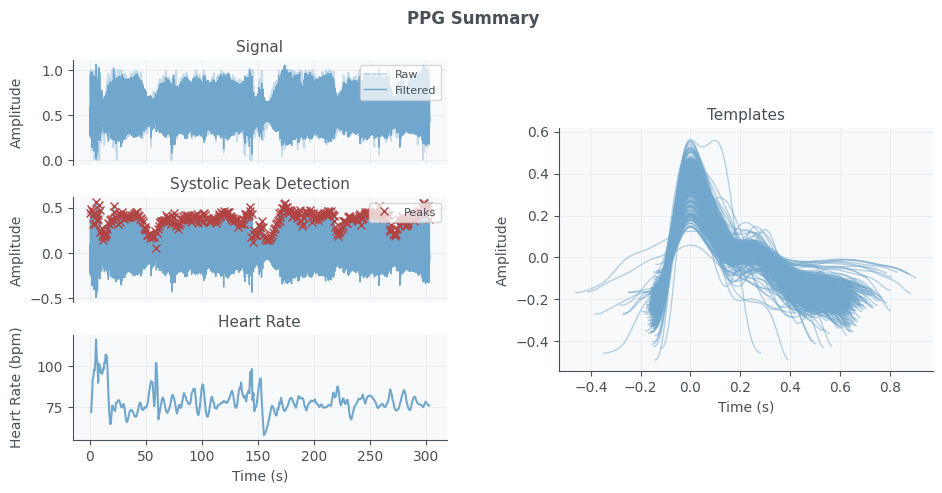

In [6]:
# 4th order butterworth bandpass filter at 0.5-8 Hz
b, a = butter(4, [0.5/  (nominal_srate / 2),
                   8 / (nominal_srate / 2)],
                   btype='bandpass')
filtered_signal = filtfilt(b, a, bvp_signal)

# peaks are marked as 1
#signals, info = nk.ppg_process(bvp_signal, sampling_rate=nominal_srate)
#print(signals)

# Get the peaks
ts, filtered_signal, peaks, _, _, hr_ts, heart_rate = ppg(bvp_signal, sampling_rate=nominal_srate, show=True)

peak_times = peaks / nominal_srate
ibi = np.diff(peak_times) * 1000  # convert to ms


   HRV_MeanNN   HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  \
0  768.083756  74.488984   17.233789   66.242695    9.484464    65.31986   

   HRV_SDANN5  HRV_SDNNI5  HRV_RMSSD   HRV_SDSD  ...  HRV_SampEn  HRV_ShanEn  \
0         NaN         NaN  55.422418  55.493064  ...    1.180978     7.43433   

   HRV_FuzzyEn  HRV_MSEn  HRV_CMSEn  HRV_RCMSEn   HRV_CD   HRV_HFD   HRV_KFD  \
0     0.812264  0.968085   1.250295    1.758136  1.39974  1.674753  2.557264   

    HRV_LZC  
0  0.787802  

[1 rows x 91 columns]


/home/mitchell/Documents/Projects/P8-Project/.venv/lib64/python3.13/site-packages/heartpy/analysis.py:522: UserWarning: Short signal.

---------Warning:---------
too few peak-peak intervals for (reliable) frequency domain measure computation, frequency output measures are still computed but treat them with caution!

HF is usually computed over a minimum of 1 minute of good signal. LF is usually computed over a minimum of 2 minutes of good signal.VLF is usually computed over a minimum of 5 minutes of good signal.The LF/HF ratio is usually computed over minimum 24 hours, although an absolute minimum of 5 min has also been suggested.

For more info see: 
Shaffer, F., Ginsberg, J.P. (2017), An Overview of Heart Rate Variability Metrics and Norms.

Task Force of Pacing and Electrophysiology (1996), Heart Rate Variability, in: European Heart Journal, vol.17, issue 3, pp354-381

This warning will not repeat
  warnings.warn(msg, UserWarning)
/home/mitchell/Documents/Projects/P8-Project/.venv/l

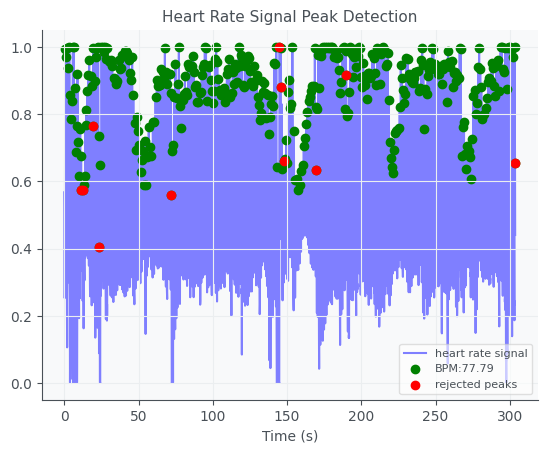

In [15]:
hrv_metrics = nk.hrv({'RRI': ibi, 'RRI_Time': peak_times[1:]}, sampling_rate=1000)
print(hrv_metrics)
wd, m = hp.process(bvp_signal, sample_rate=nominal_srate, calc_freq=True)
hp.plotter(wd, m)


In [26]:
bvp_df    = pd.DataFrame({'BVP': bvp_signal}, index=pd.to_datetime(bvp_ts, unit='s'))
events_df = pd.DataFrame({'time': pd.to_datetime(mark_ts, unit='s'), 'event': marks})
aligned   = pd.merge_asof(events_df.sort_values('time'), bvp_df, left_on='time', right_index=True, direction='nearest')

print(aligned)

Empty DataFrame
Columns: [time, event, BVP]
Index: []
